In [127]:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score


# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [128]:
pd.set_option('display.max_columns', None)
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [130]:
# Drop columns
df = df.drop(columns=['customerID'])

In [131]:
#check for unique values in all categorical columns
num_list = ['tenure', 'TotalCharges', 'MonthlyCharges']
for col in df.columns:
  if col not in num_list:
    print(f"{col}: {df[col].unique()} : Type-{df[col].dtype}")
    print('-'*40)

gender: ['Female' 'Male'] : Type-object
----------------------------------------
SeniorCitizen: [0 1] : Type-int64
----------------------------------------
Partner: ['Yes' 'No'] : Type-object
----------------------------------------
Dependents: ['No' 'Yes'] : Type-object
----------------------------------------
PhoneService: ['No' 'Yes'] : Type-object
----------------------------------------
MultipleLines: ['No phone service' 'No' 'Yes'] : Type-object
----------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No'] : Type-object
----------------------------------------
OnlineSecurity: ['No' 'Yes' 'No internet service'] : Type-object
----------------------------------------
OnlineBackup: ['Yes' 'No' 'No internet service'] : Type-object
----------------------------------------
DeviceProtection: ['No' 'Yes' 'No internet service'] : Type-object
----------------------------------------
TechSupport: ['No' 'Yes' 'No internet service'] : Type-object
------------------------

In [132]:
display(df[df['tenure']==0].head(12))

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [133]:
# Total charges is a float but represented as object
# Replacing empty strings with '0.0', still as object
df['TotalCharges'] = df['TotalCharges'].replace({' ':'0.0'})

# Now Converting all to float
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [134]:
# Check the class distribution of target column(Churn) for imbalance
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [135]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [136]:
# Define a function to plot the numerical columns distribution
def plot_hist(df, col_name):
  plt.figure(figsize=(10,5))
  sns.histplot(data=df, x=col_name, kde=True)
  plt.title(f"Distribution of {col_name}")

  # Calculate the mean and median for columns
  col_mean = df[col_name].mean()
  col_median = df[col_name].median()

  # Draw vertical lines
  plt.axvline(col_mean, color='red', linestyle='--', linewidth= 2, label=f'Mean: {col_mean:.2f}')
  plt.axvline(col_median, color='green', linestyle='-', linewidth= 2, label=f'Median: {col_median:.2f}')

  plt.legend()
  plt.show()

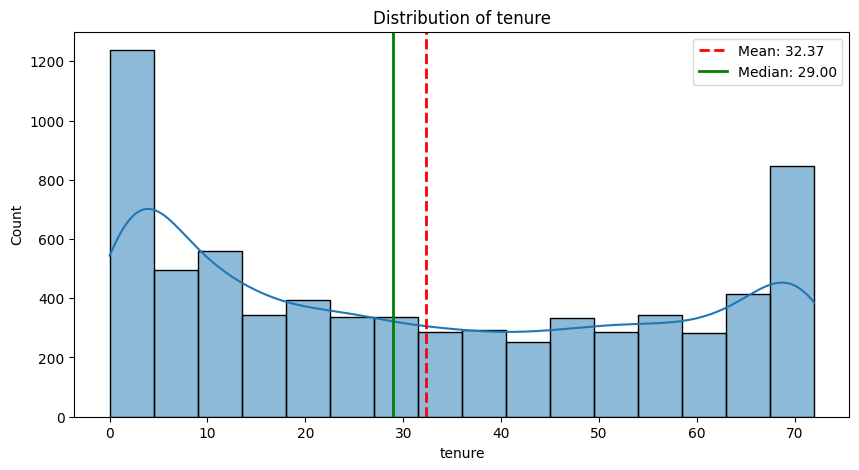

In [137]:
plot_hist(df, 'tenure')

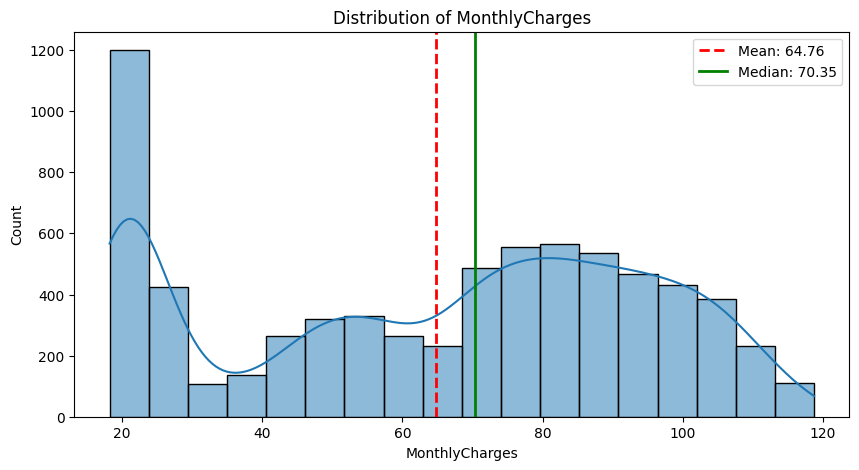

In [138]:
plot_hist(df, 'MonthlyCharges')

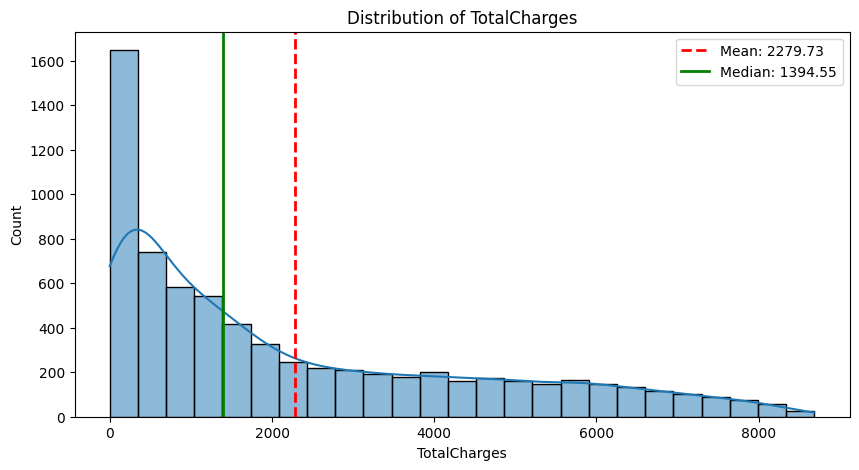

In [139]:
plot_hist(df, 'TotalCharges')

In [140]:
# The box plot to see if we have any outliers in the columns
def plot_boxplot(df, col_name):
  plt.figure(figsize=(10,5))
  sns.boxplot(data=df, y=col_name)
  plt.title(f"Boxplot of {col_name}")
  plt.show()

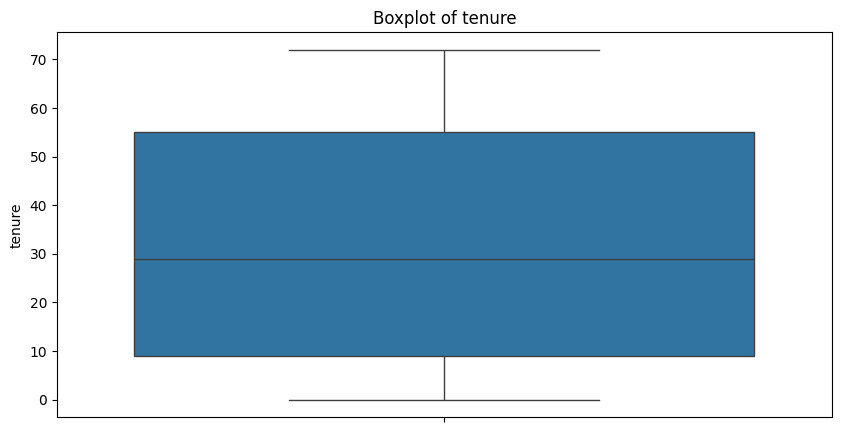

In [141]:
plot_boxplot(df, 'tenure')

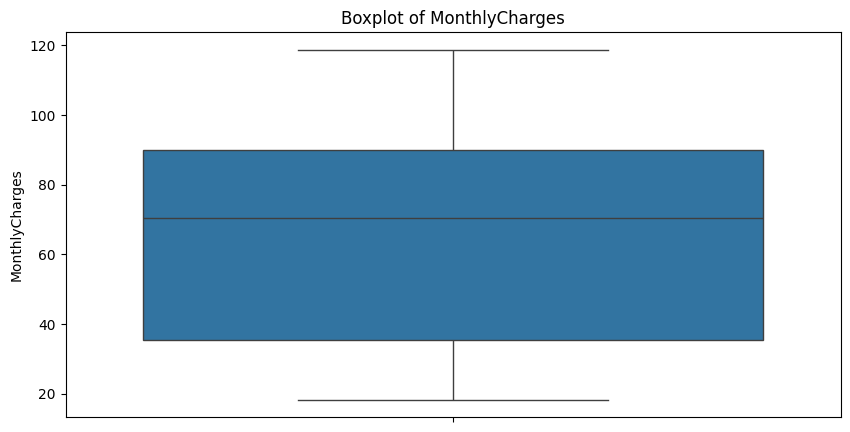

In [142]:
plot_boxplot(df, 'MonthlyCharges')

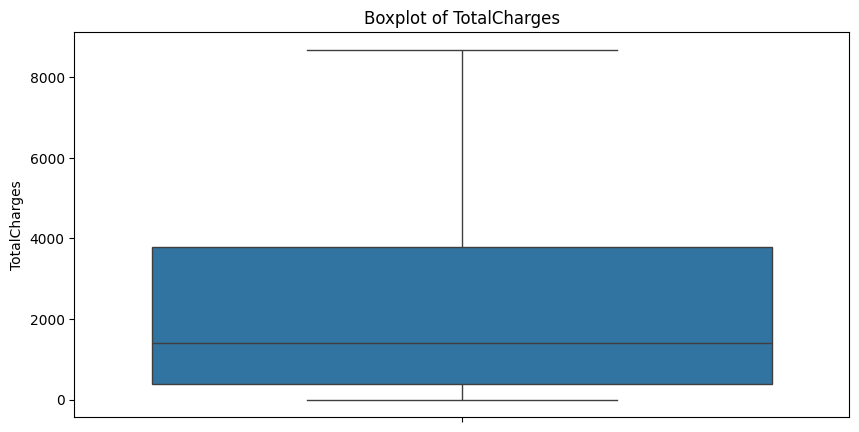

In [143]:
plot_boxplot(df, 'TotalCharges')

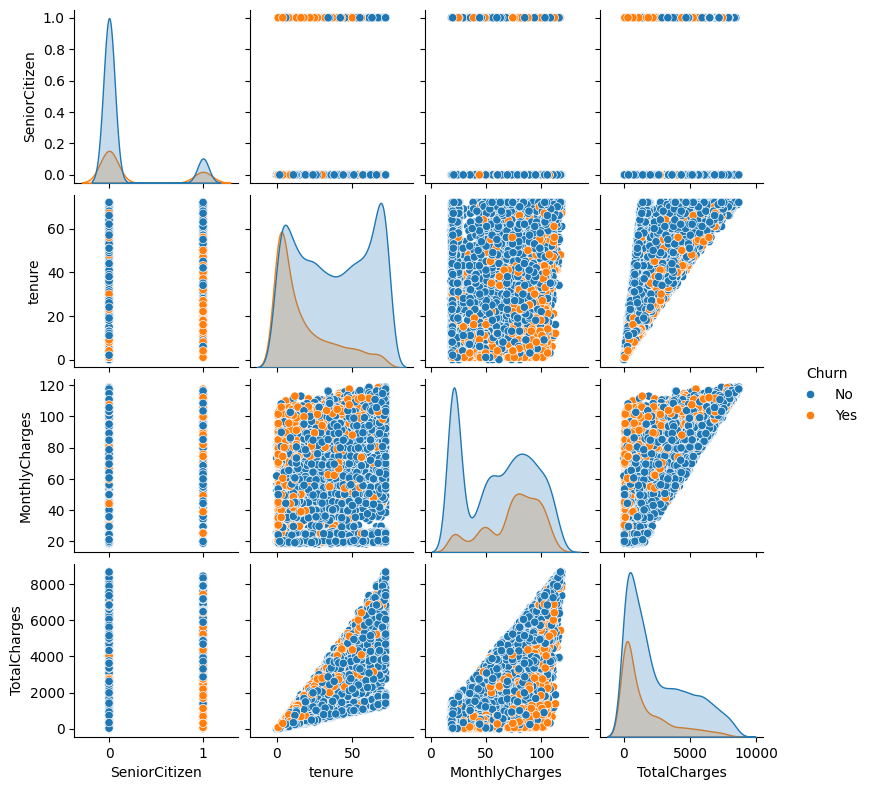

In [144]:
sns.pairplot(df, hue='Churn', height=2)
plt.show()

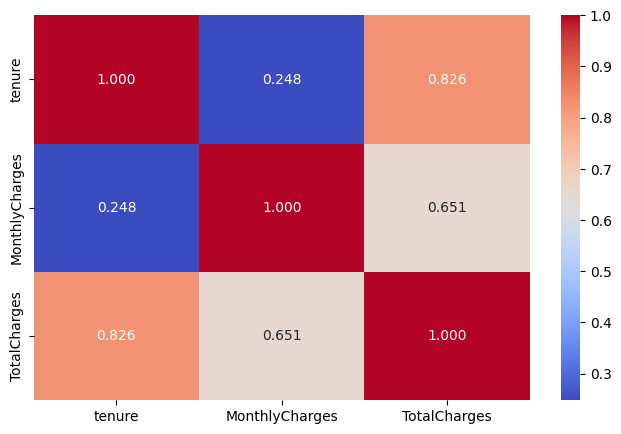

In [145]:
# plot a heatmap coorelation for numerical columns

plt.figure(figsize=(8,5))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.show()

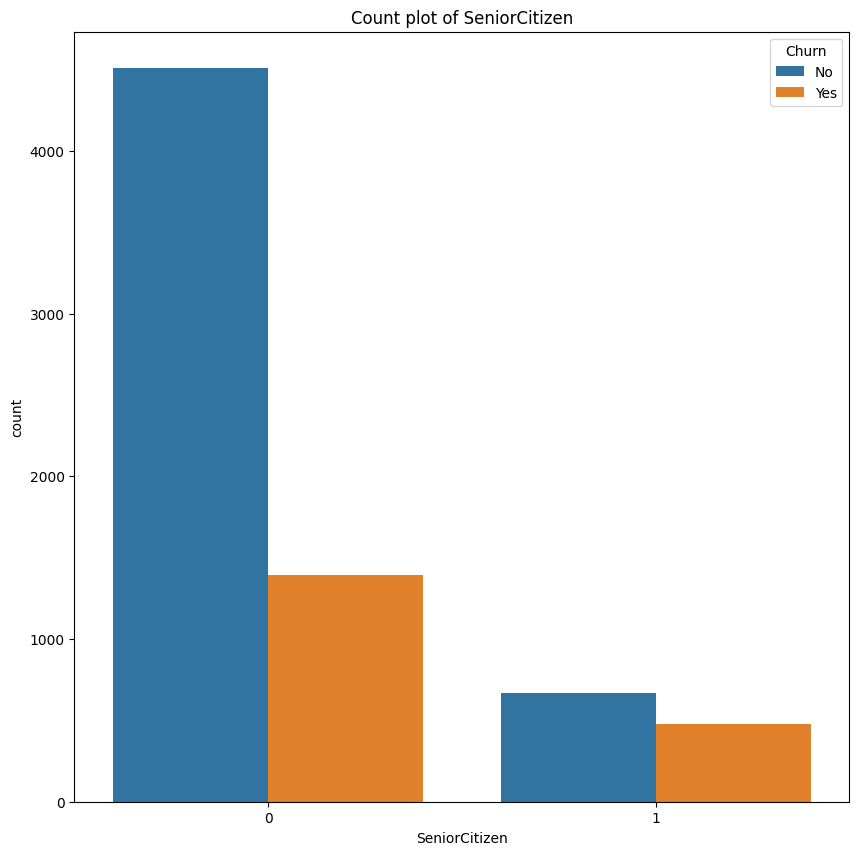

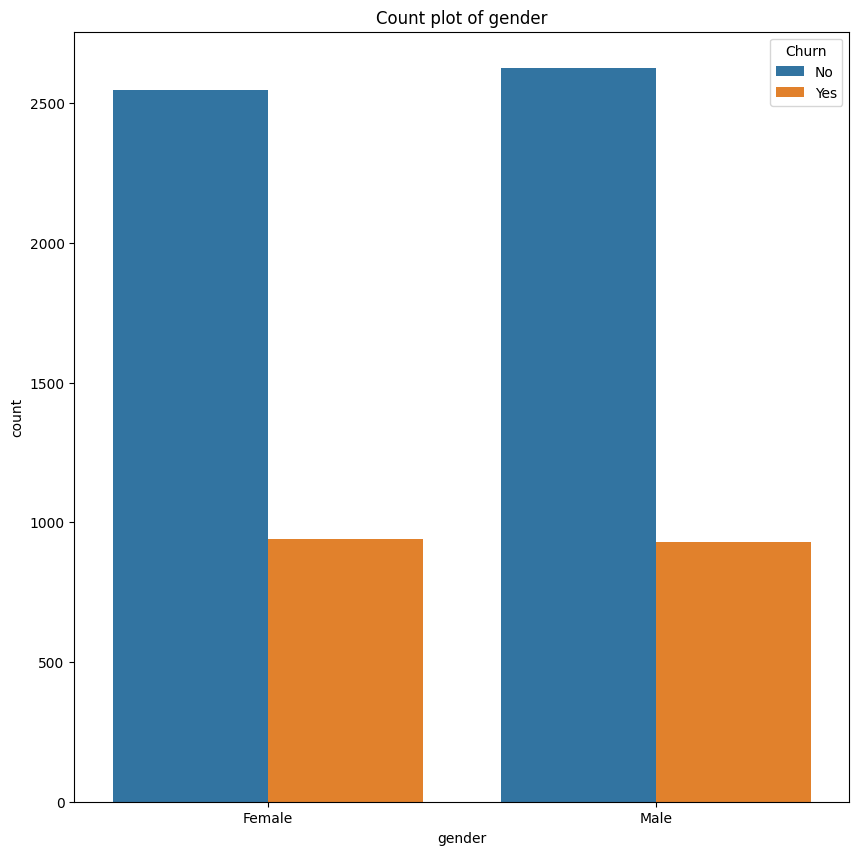

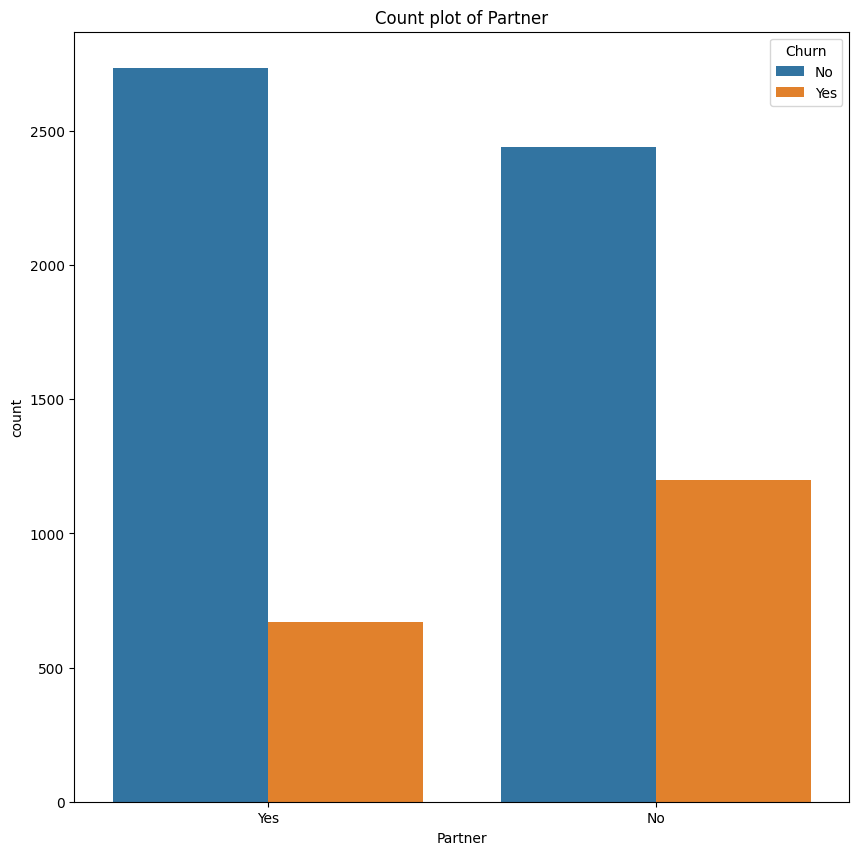

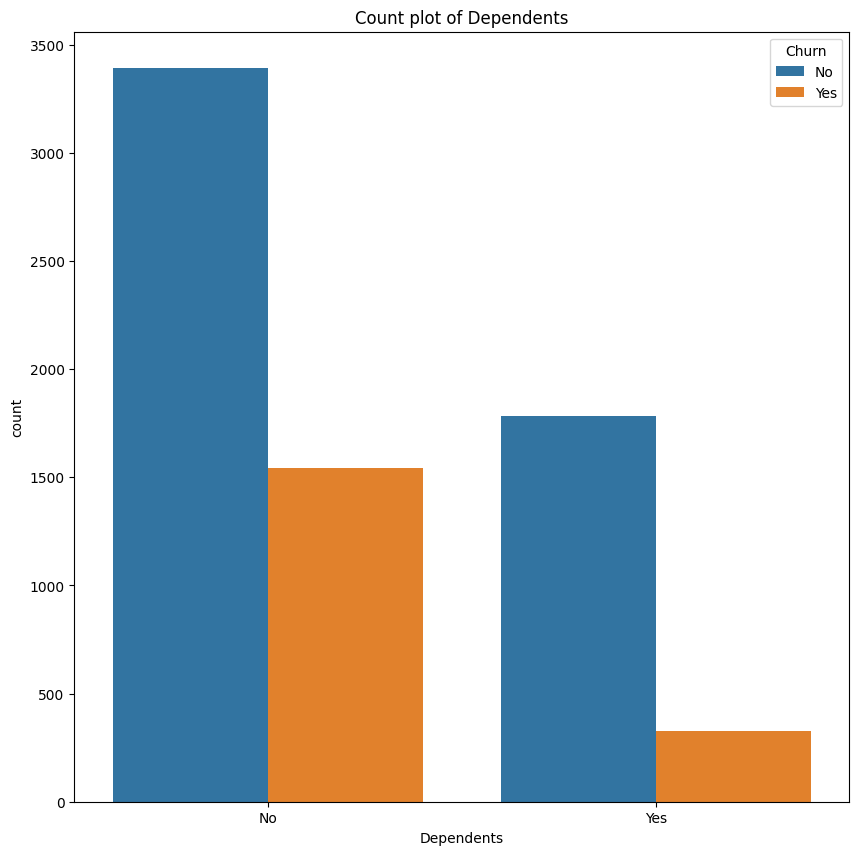

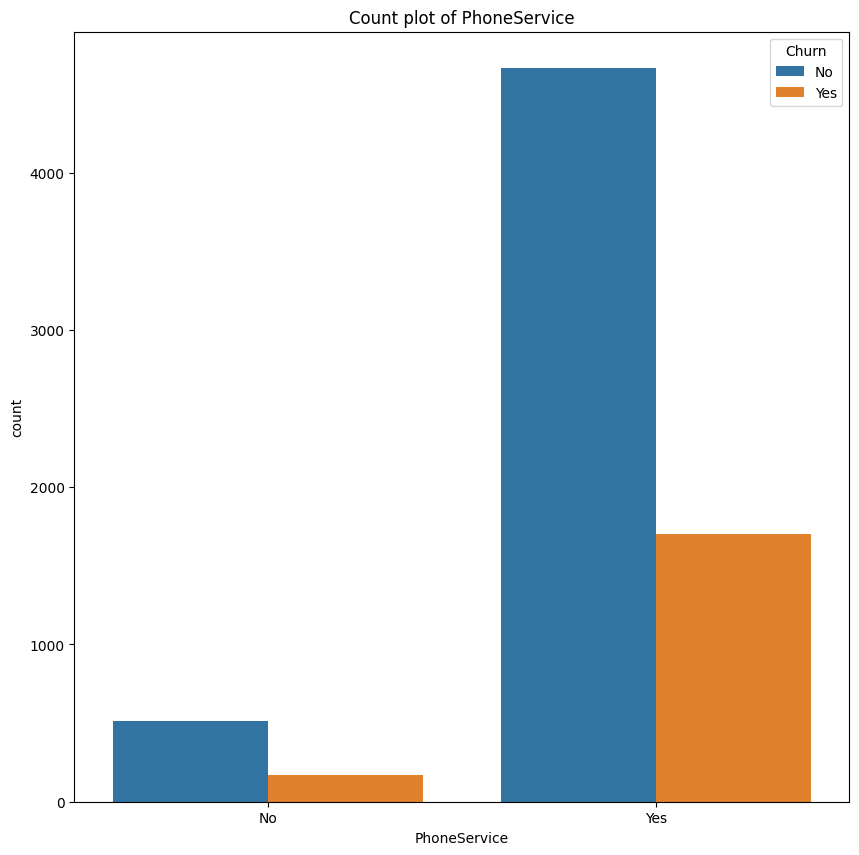

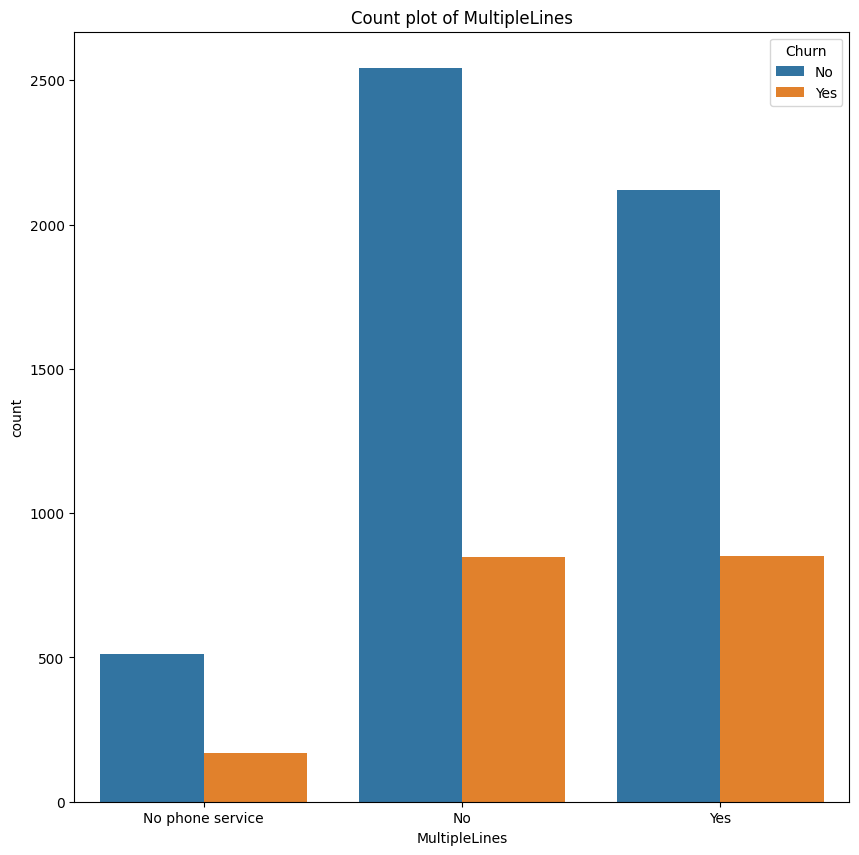

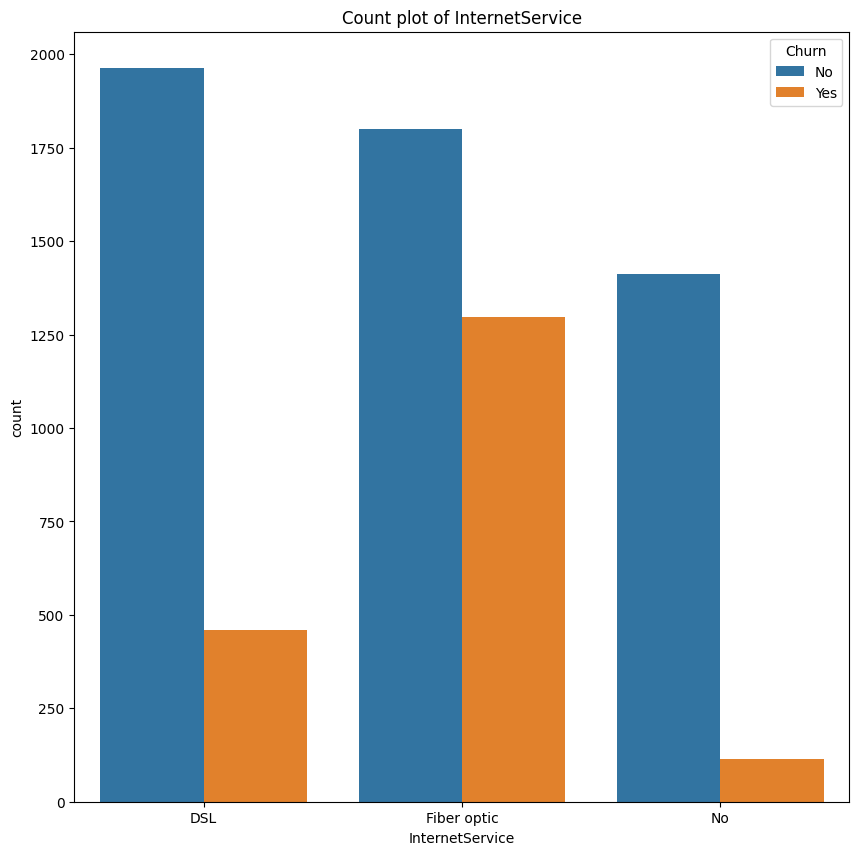

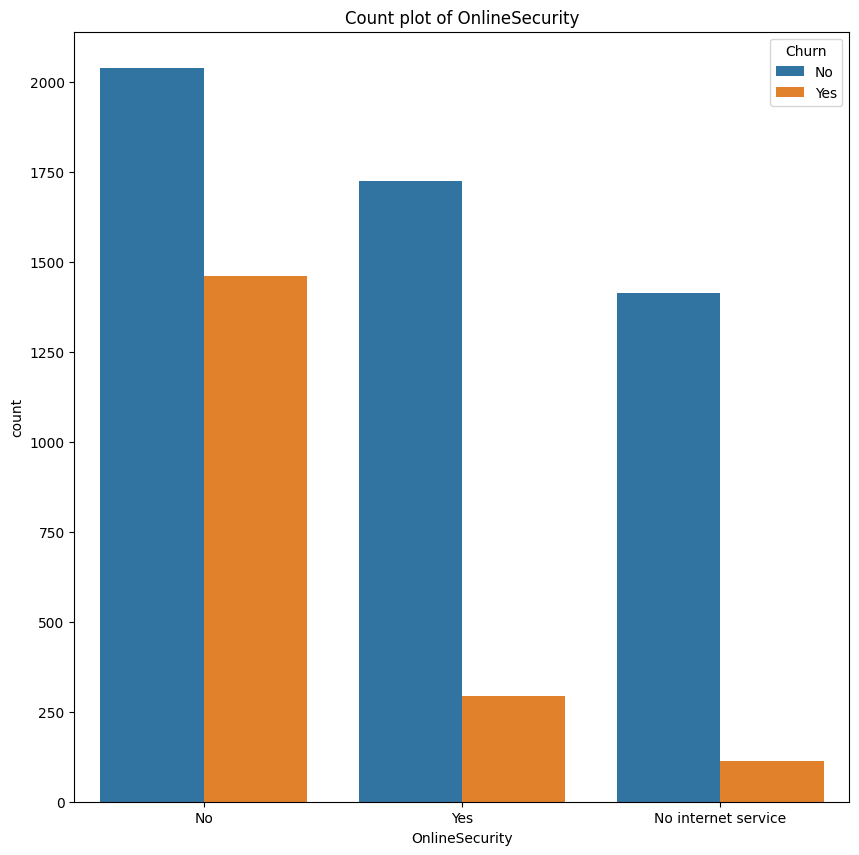

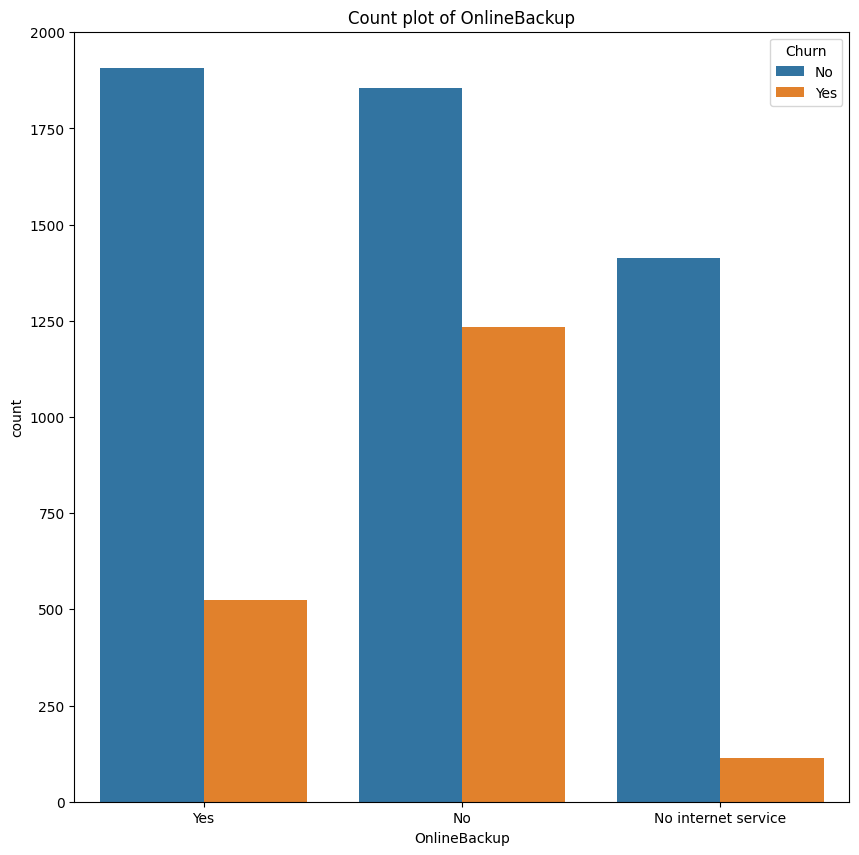

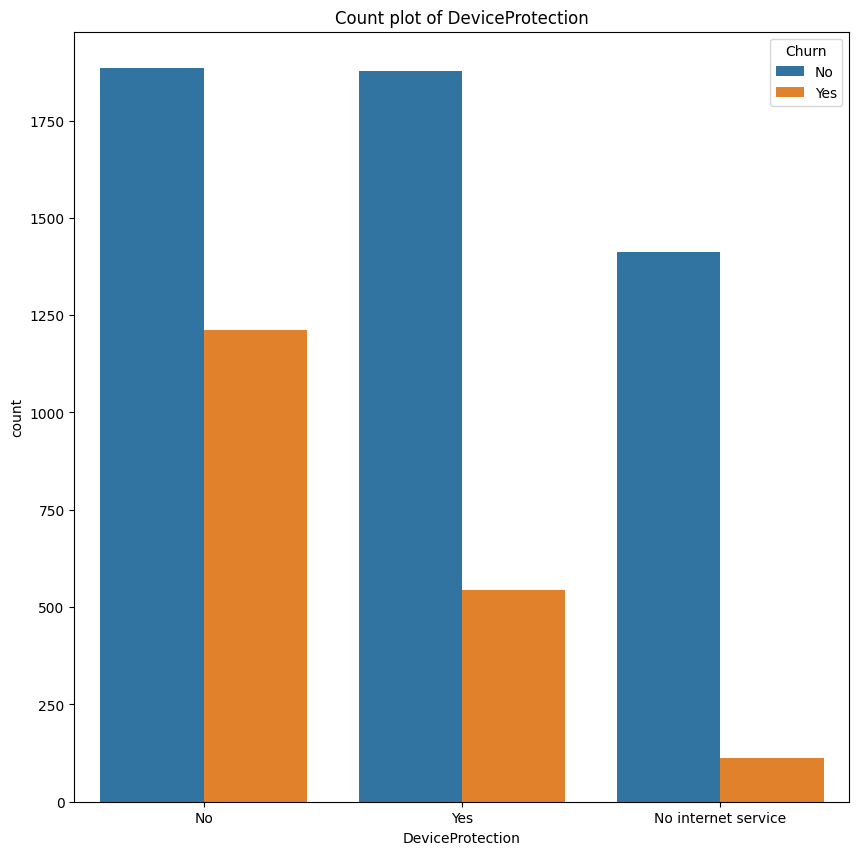

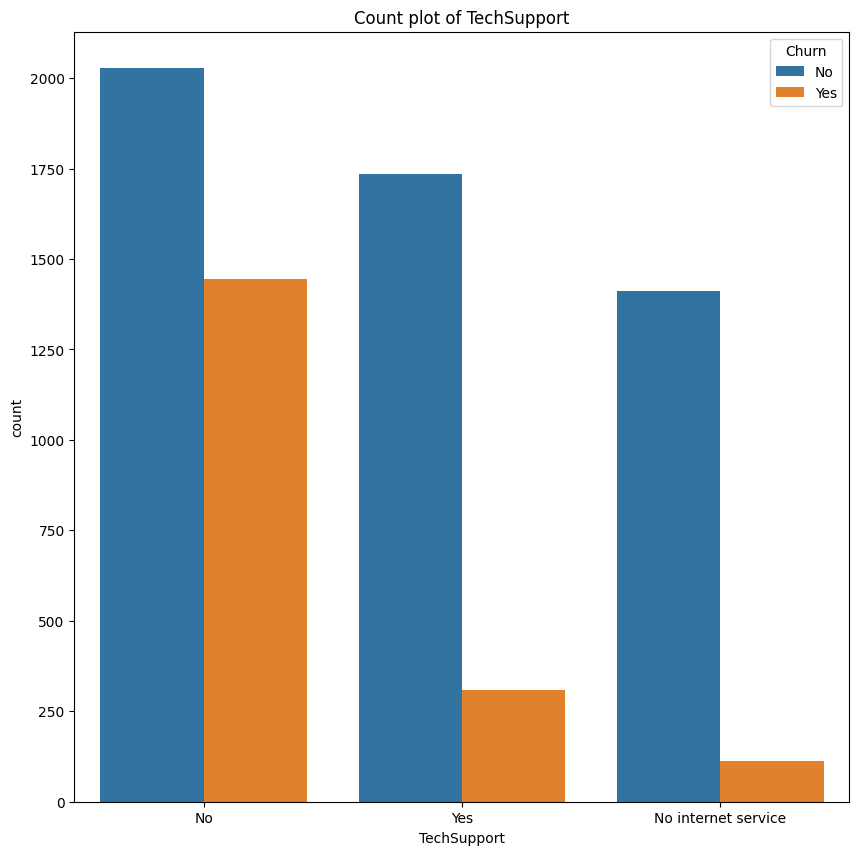

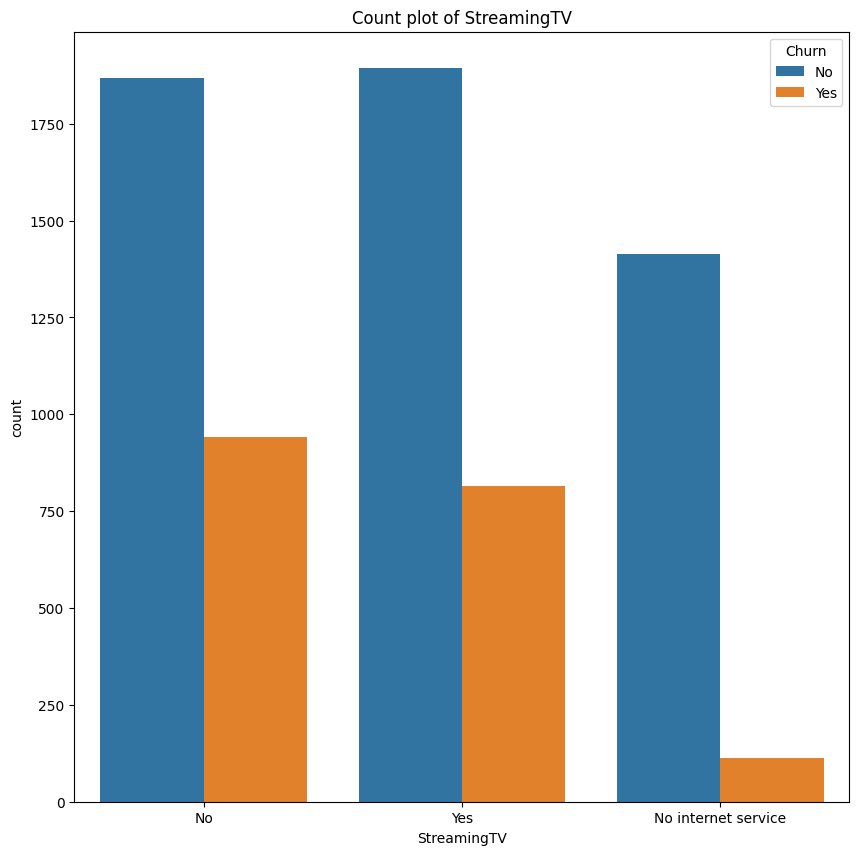

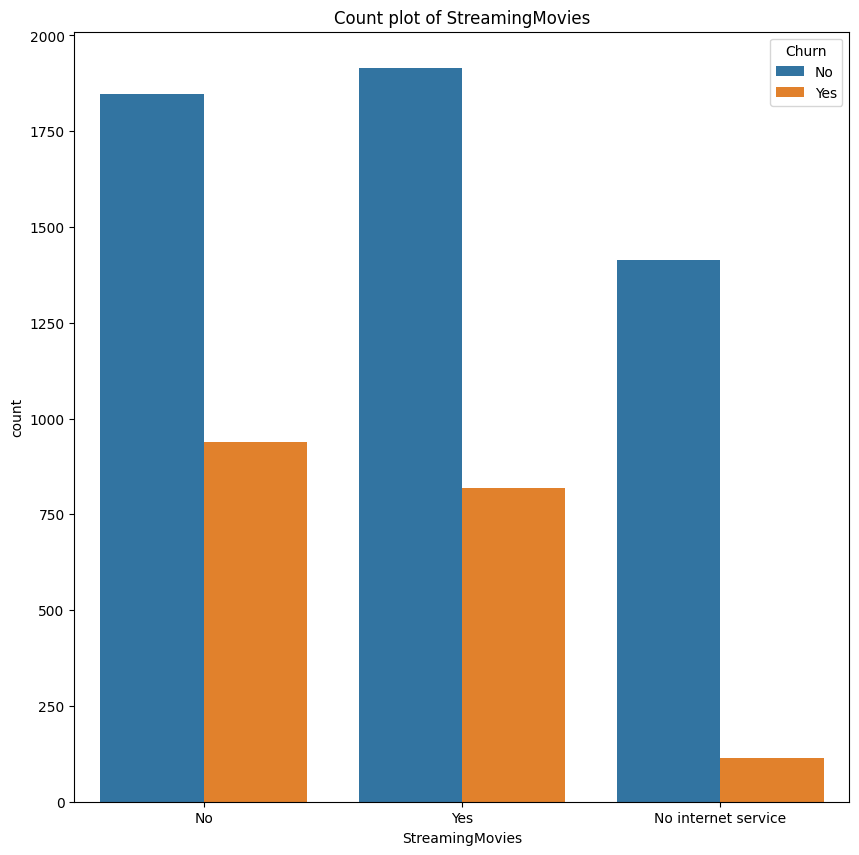

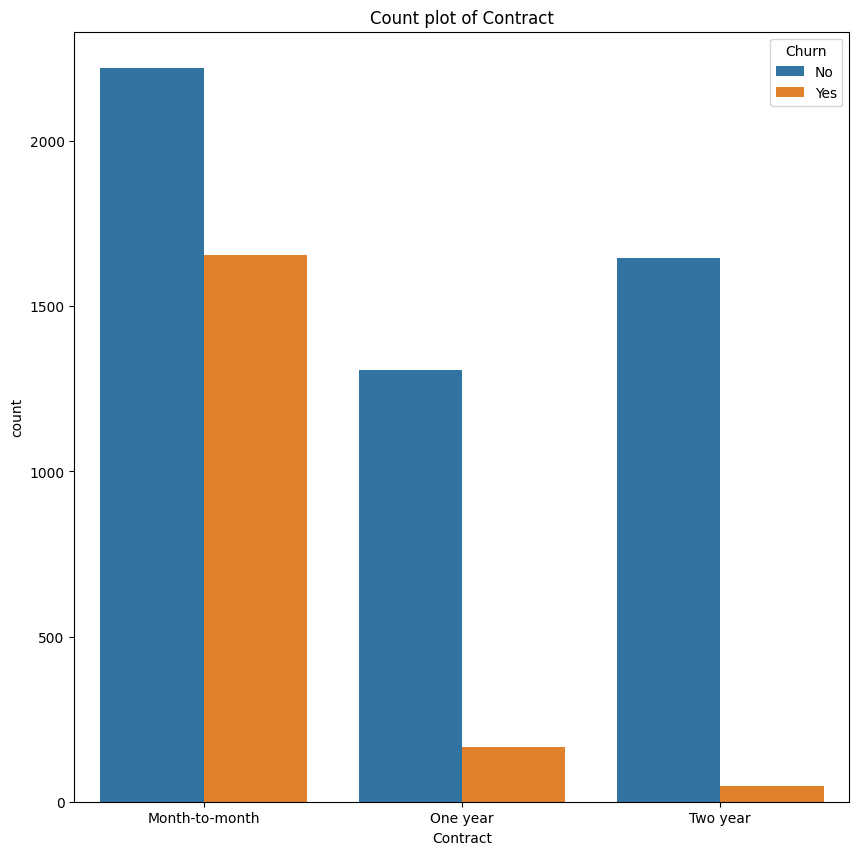

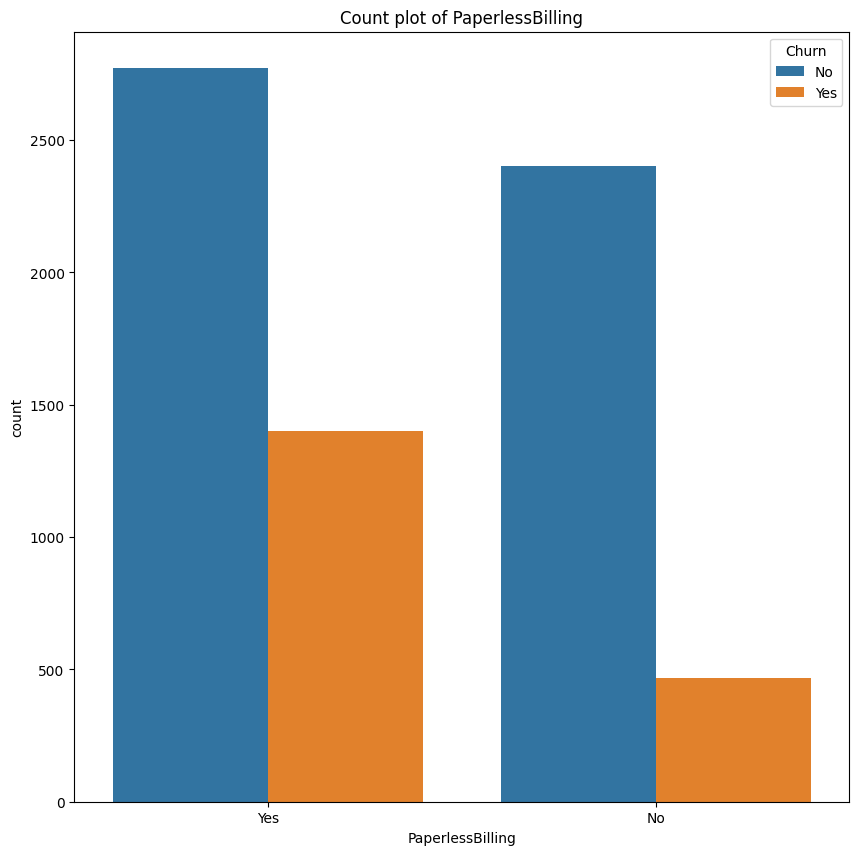

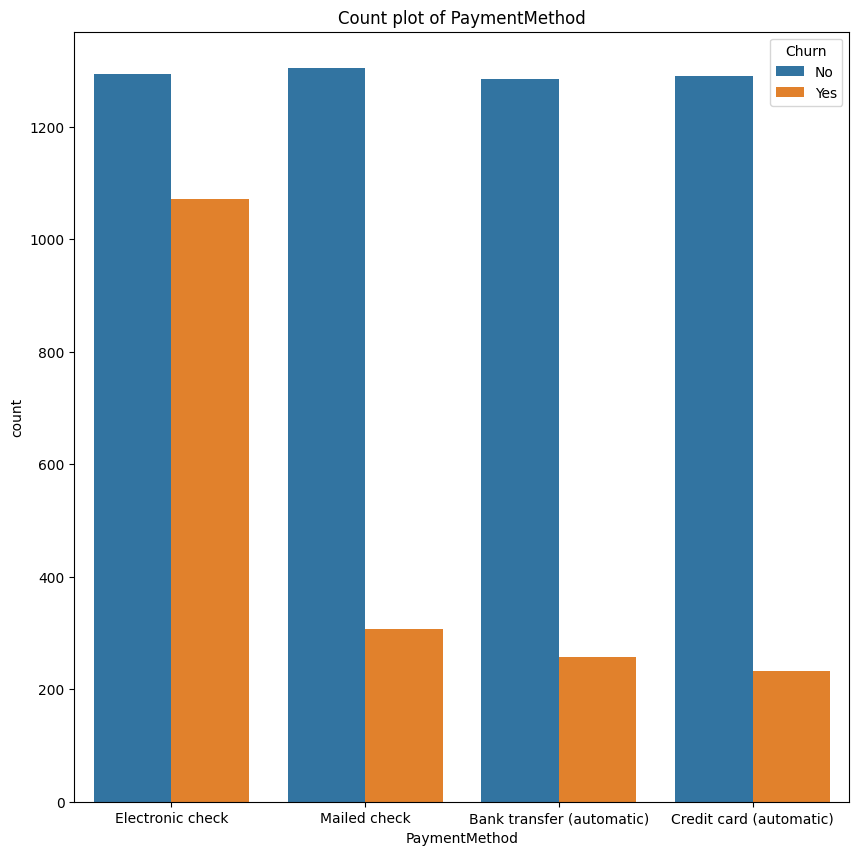

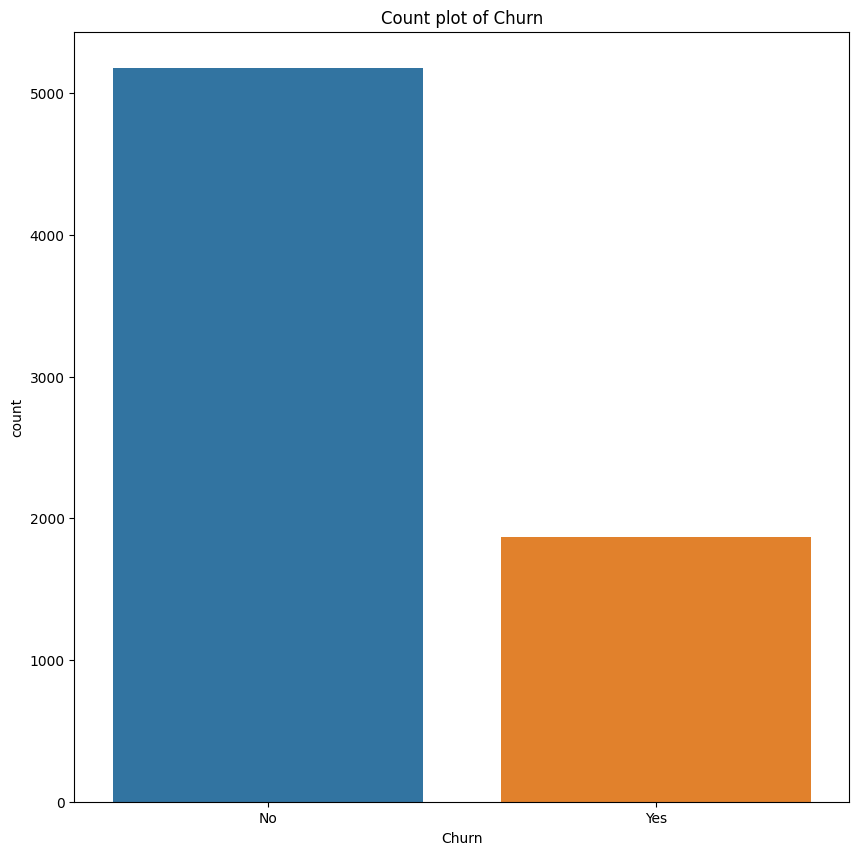

In [146]:
# Count plot for categorical columns

object_cols = df.select_dtypes(include='object').columns.tolist()
object_cols = ['SeniorCitizen'] + object_cols

for col in object_cols:
  plt.figure(figsize=(10,10))
  sns.countplot(data=df, x=df[col], hue='Churn')
  plt.title(f"Count plot of {col}")
  plt.show()

In [147]:
# Encode / Map categorical columns

# Initialize a dictionary to save the encoders
encoders = {}

categorical_cols = df.select_dtypes(include='object').columns.tolist()
# categorical_cols.remove(df['gender'])

for col in categorical_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoders[col] = le

# Save the encoders to a pickle file
import pickle
with open('encoders.pkl', 'wb') as f:
  pickle.dump(encoders, f)

In [148]:
display(encoders)

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

In [149]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


**SPLIT THE TRAIN AND TEST**

In [151]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=98)

In [152]:
print(y_train.shape)

(5634,)


In [153]:
print(y_train.value_counts())

Churn
0    4107
1    1527
Name: count, dtype: int64


**APPLY SMOTE (Synthetic Minority Over-sampling TEchnique) to balance the Churn column for consistency**

In [154]:
# Resampling only the Train split dataset
smote = SMOTE(random_state=98)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [155]:
print(f"Value counts: {y_train_resampled.value_counts()}")
print("After Resampling, Churn are now evenly distributed to avoid overfitting/underfitting the model")

Value counts: Churn
0    4107
1    4107
Name: count, dtype: int64
After Resampling, Churn are now evenly distributed to avoid overfitting/underfitting the model


In [156]:
print(f"Shape: {y_train_resampled.shape}")

Shape: (8214,)


**Train Models**

In [157]:
models = [
    ('Logistic Regression', LogisticRegression(random_state=98, max_iter=5000)),
    ('Random Forest', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        # class_weight='balanced'
    )),
    ('XGBoost', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=98,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        eval_metric='logloss',
        scale_pos_weight=1.5
    )),
]

for name, model in models:
  print(f"Training {name}...")
  model.fit(X_train_resampled, y_train_resampled)
  print(f"{name} trained successfully")
  print('-'*40)
  print(f"Training Score: {model.score(X_train_resampled, y_train_resampled)}")
  print(f"Testing Score: {model.score(X_test, y_test)}")
  print('-'*40)
  y_pred = model.predict(X_test)
  print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
  print('-'*40)
  print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")
  print('-'*40)
  print(f"Classification Report: \n{classification_report(y_test, y_pred)}")
  print('-'*40)

  y_prob = model.predict_proba(X_test)[:, 1]

  roc_auc = roc_auc_score(y_test, y_prob)
  pr_auc  = average_precision_score(y_test, y_prob)

  print(f"ROC_AUC: \n{roc_auc}")
  print('-'*40)
  print(f"PR_AUC: \n{pr_auc}")
  print('-'*40)

Training Logistic Regression...
Logistic Regression trained successfully
----------------------------------------
Training Score: 0.8039931823715607
Testing Score: 0.759403832505323
----------------------------------------
Accuracy Score: 0.759403832505323
----------------------------------------
Confusion Matrix: 
[[823 244]
 [ 95 247]]
----------------------------------------
Classification Report: 
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1067
           1       0.50      0.72      0.59       342

    accuracy                           0.76      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.76      0.77      1409

----------------------------------------
ROC_AUC: 
0.8289651808371287
----------------------------------------
PR_AUC: 
0.5669302833402785
----------------------------------------
Training Random Forest...
Random Forest trained successfully
---------------------------

## Calculate Churn Rate for Categorical Features

Calculate and visualize the churn rate for each category within the categorical features of the `df_temp` dataframe. Then, create visualizations for the numerical features ('tenure', 'MonthlyCharges', 'TotalCharges') from `df_temp` to show their distribution against customer churn. Finally, extract and visualize feature importance scores from the trained XGBoost model.

In [168]:
churn_rate_df = df_temp.copy()

# Identify categorical columns
categorical_features = churn_rate_df.select_dtypes(include='object').columns.tolist()

# 'Churn' is the target, so exclude it from features for calculating churn rates by other features
if 'Churn' in categorical_features:
    categorical_features.remove('Churn')

print(f"Categorical features identified for churn rate calculation: {categorical_features}")

Categorical features identified for churn rate calculation: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Iterate through each categorical feature, calculate the churn rate for each category within that feature, and then visualize these churn rates using bar plots as instructed.



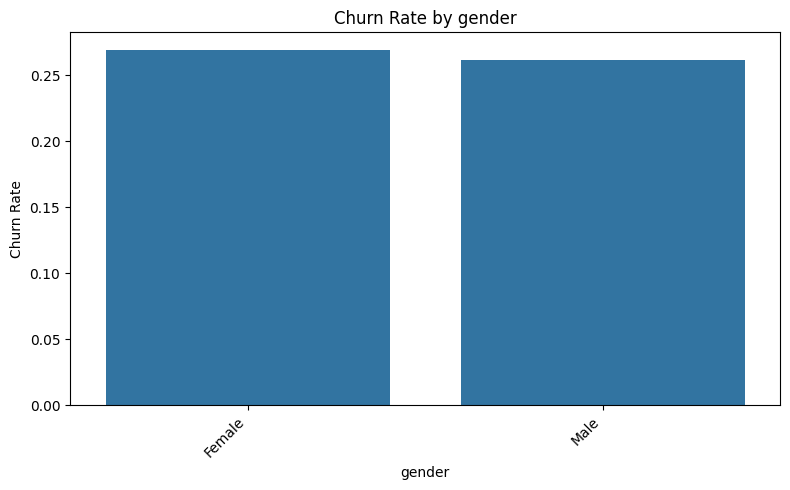

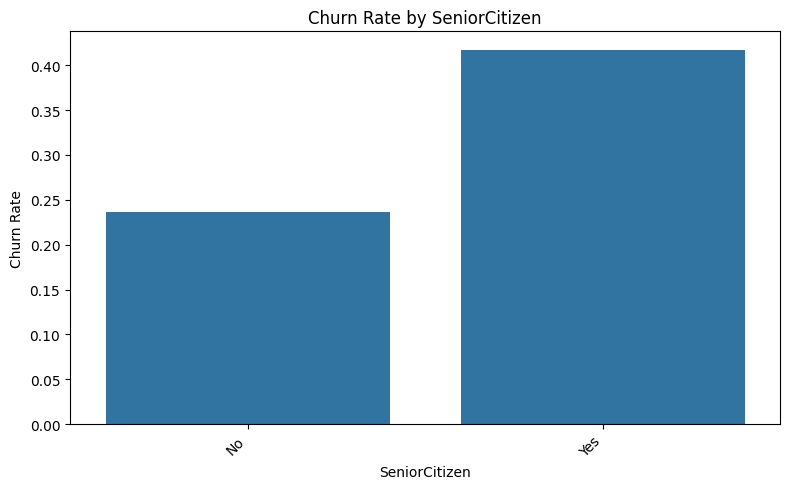

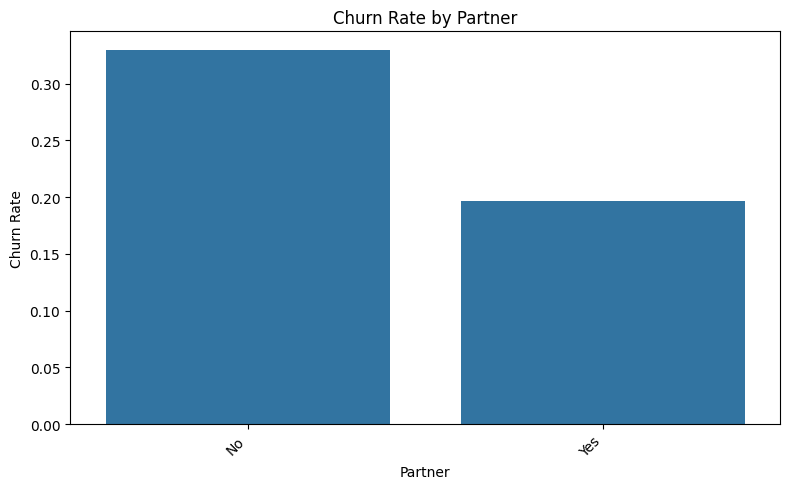

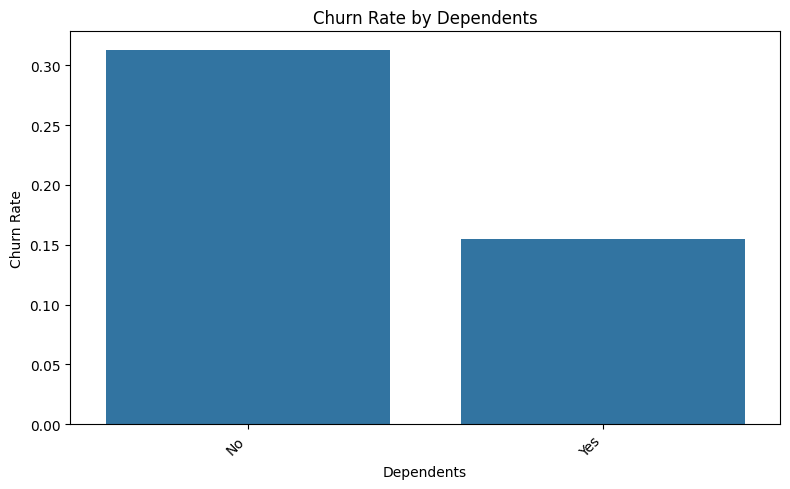

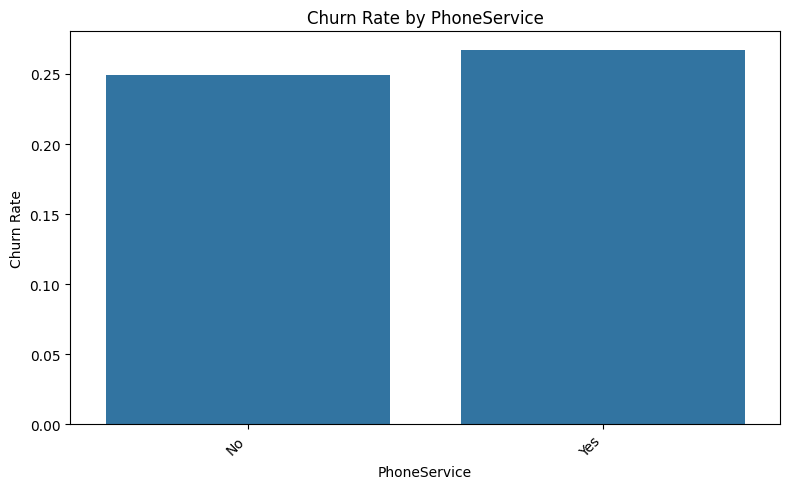

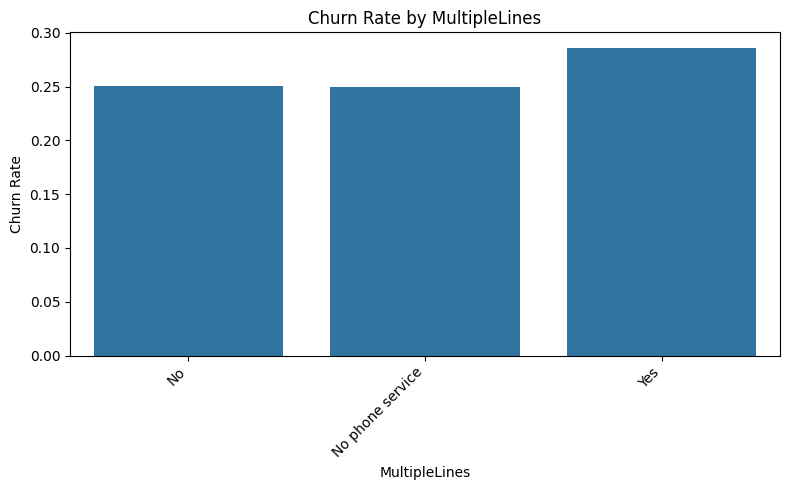

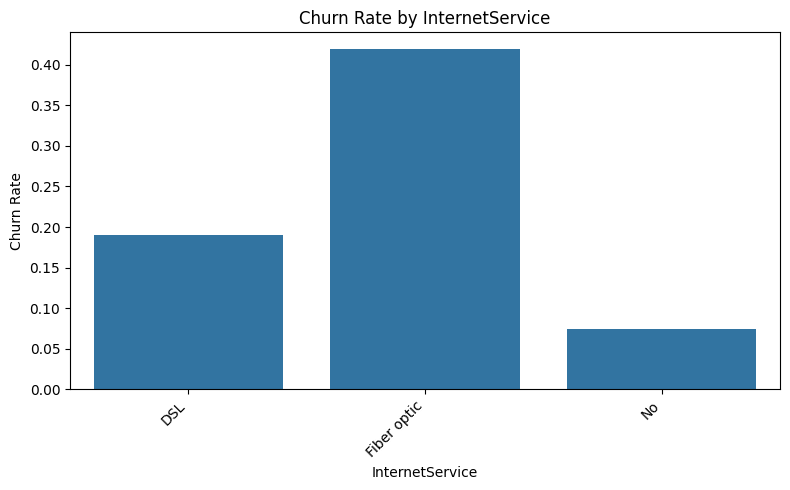

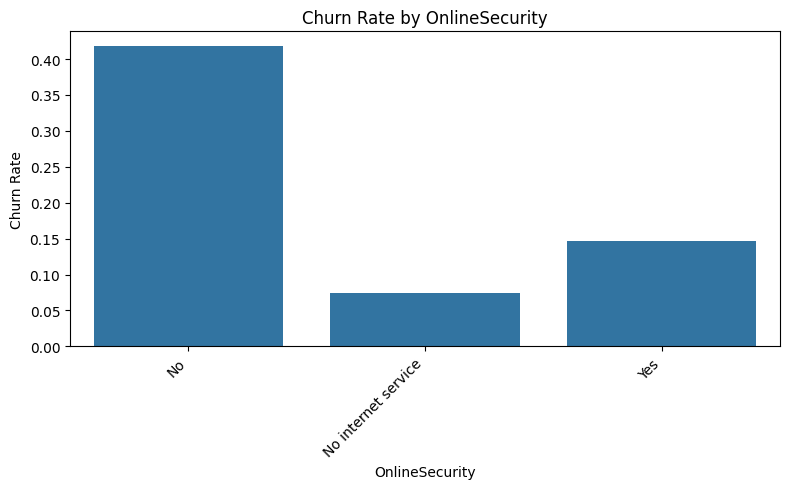

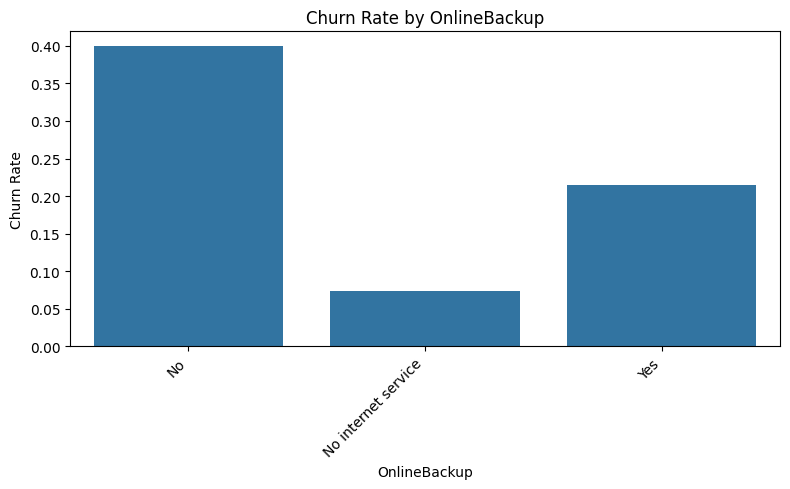

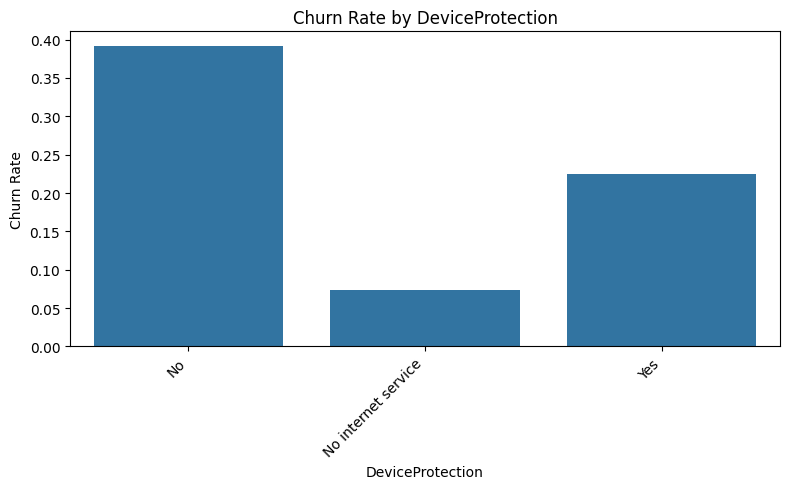

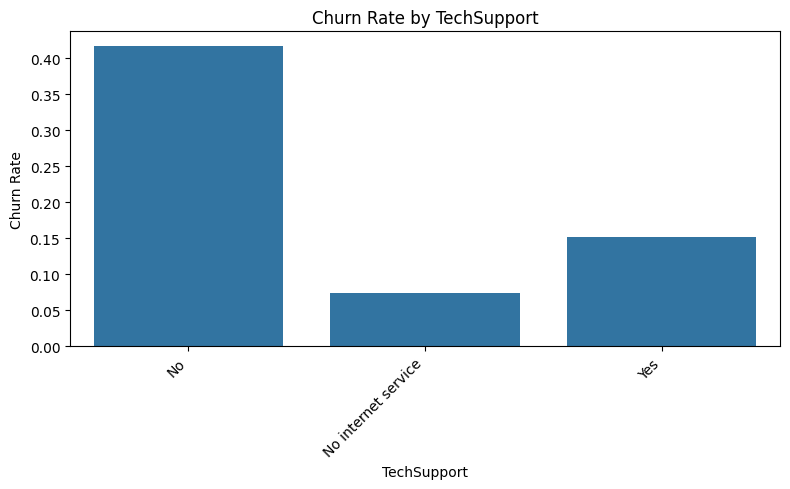

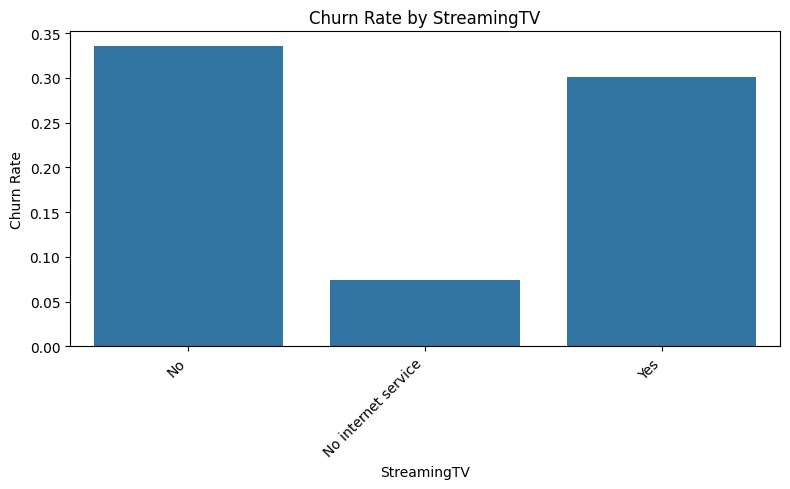

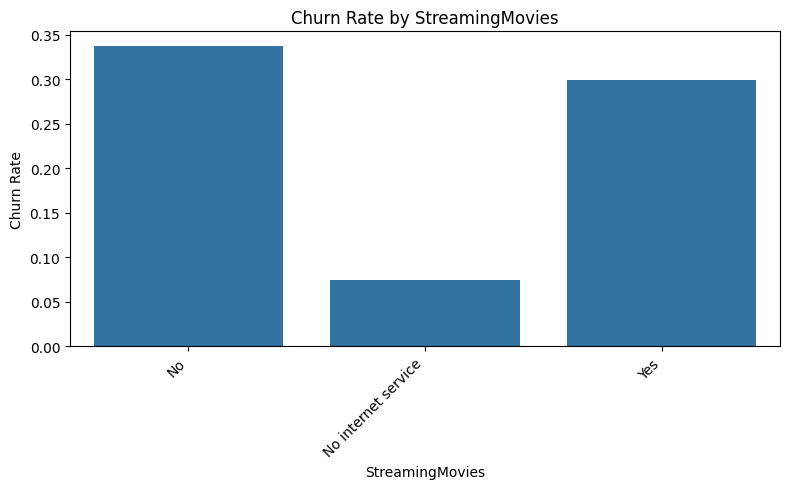

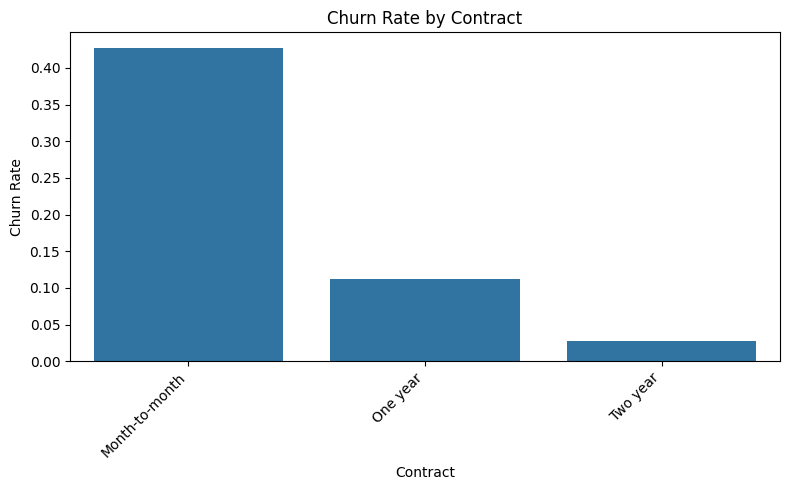

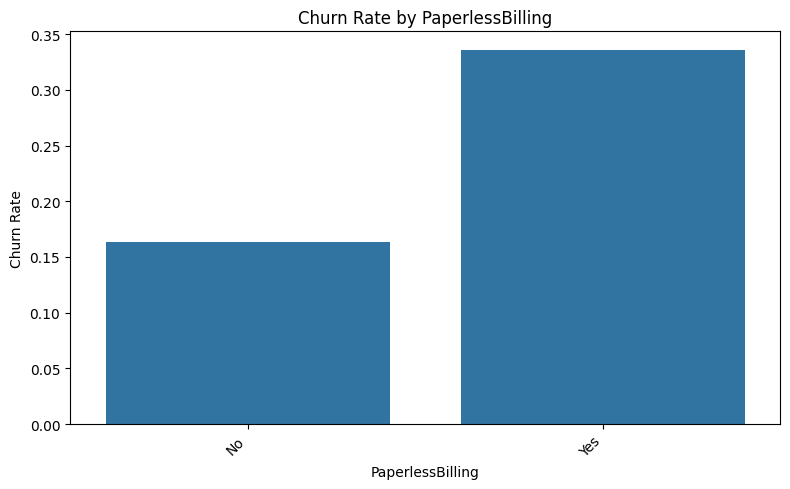

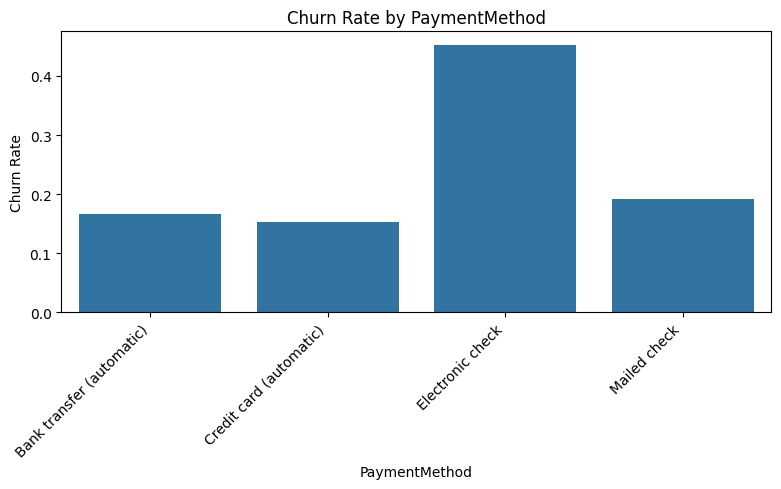

In [169]:
for col in categorical_features:
    # Group by the current categorical column and 'Churn', then count occurrences
    churn_counts = churn_rate_df.groupby([col, 'Churn']).size().unstack(fill_value=0)

    # Calculate churn rate
    churn_counts['ChurnRate'] = churn_counts.get('Yes', 0) / (churn_counts.get('No', 0) + churn_counts.get('Yes', 0))

    # Plotting
    plt.figure(figsize=(8, 5))
    sns.barplot(x=churn_counts.index, y=churn_counts['ChurnRate'])
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Visualize Numerical Features Against Churn

Create visualizations for the numerical features ('tenure', 'MonthlyCharges', 'TotalCharges') from `df_temp` to show their distribution against customer churn.

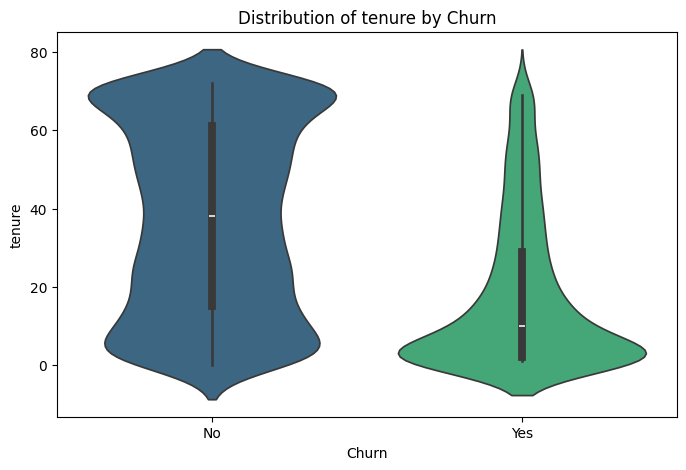

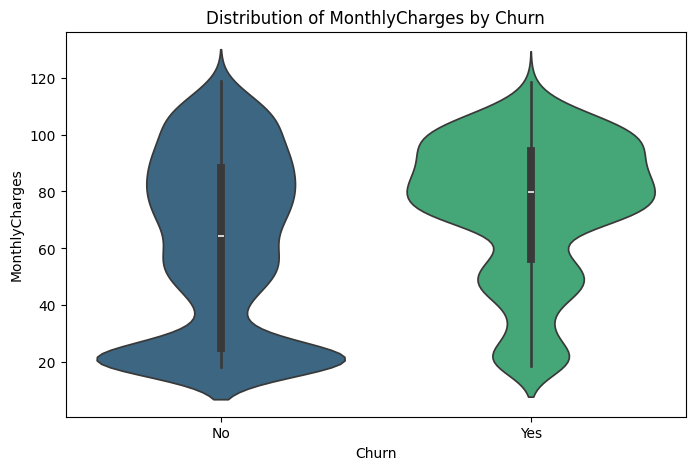

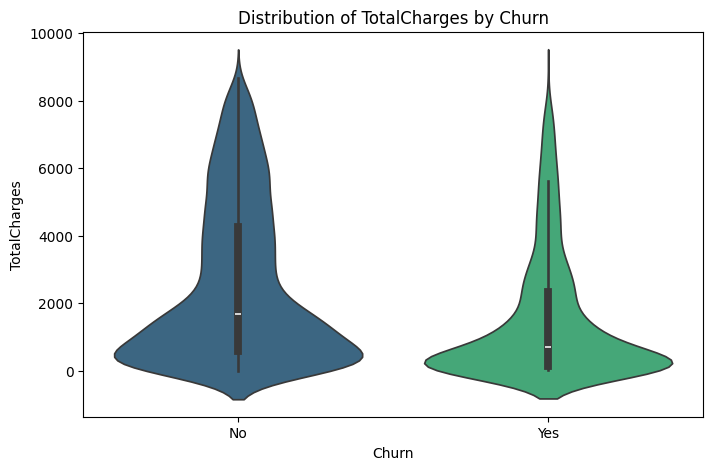

In [175]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df_temp, x='Churn', y=col, palette='viridis', hue='Churn', legend=False)
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()

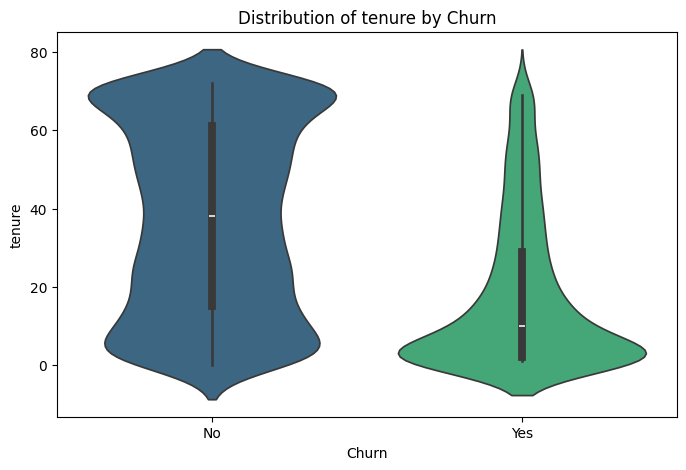

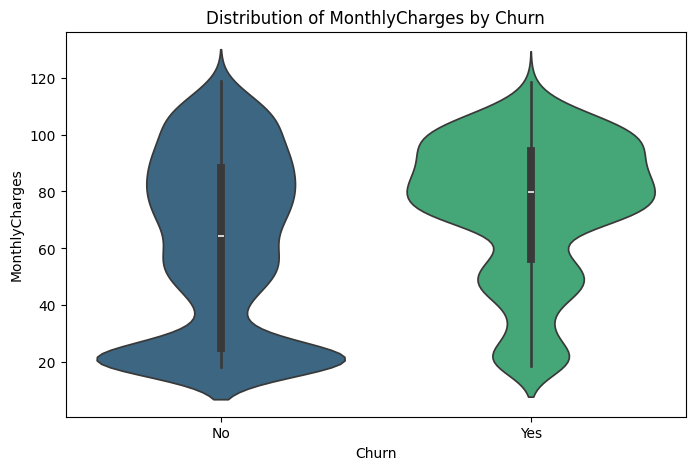

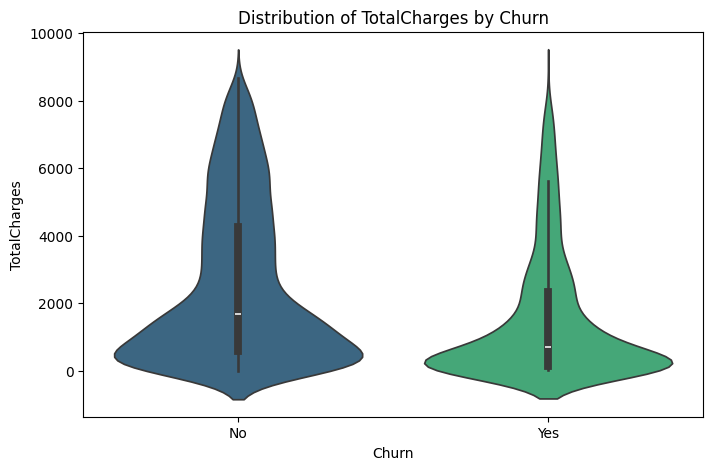

In [171]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df_temp, x='Churn', y=col, palette='viridis', hue='Churn', legend=False)
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()

## Visualize Feature Importance from XGBoost Model

Extract and visualize feature importance scores from the trained XGBoost model.

In [172]:
xgboost_model = None
for name, model in models:
    if name == 'XGBoost':
        xgboost_model = model
        break

if xgboost_model:
    # Get feature importances
    feature_importances = xgboost_model.feature_importances_

    # Map feature importances to column names
    feature_names = X_train_resampled.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # Sort by importance
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print("Top 10 Feature Importances from XGBoost Model:")
    print(importance_df.head(10))
else:
    print("XGBoost model not found in the trained models list.")

Top 10 Feature Importances from XGBoost Model:
             Feature  Importance
14          Contract    0.409873
8     OnlineSecurity    0.074246
7    InternetService    0.068001
11       TechSupport    0.051593
5       PhoneService    0.051228
9       OnlineBackup    0.045647
10  DeviceProtection    0.029098
3         Dependents    0.028811
6      MultipleLines    0.027051
13   StreamingMovies    0.024178



The feature importances have been extracted and sorted, I will visualize them using a bar plot to clearly show the most influential features as identified by the XGBoost model.



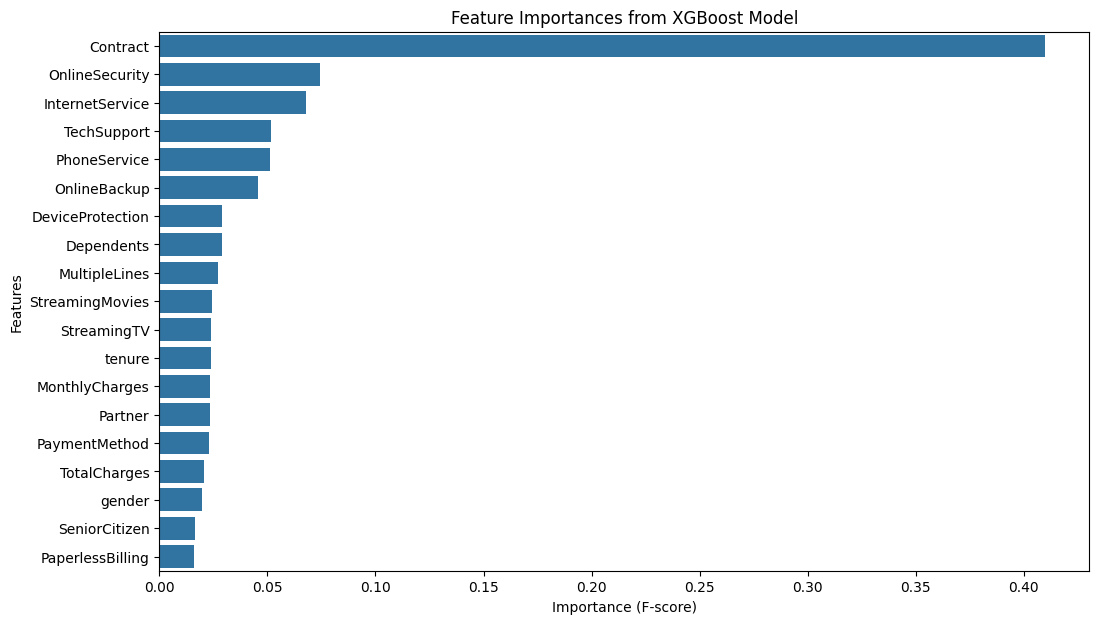

In [173]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from XGBoost Model')
plt.xlabel('Importance (F-score)')
plt.ylabel('Features')
plt.show()